# Age Pyramid Examples

We will use a U.S. age pyramid and a Nigerian age pyramid for examples.

In [1]:
from pathlib import Path

import numpy as np

from laser.core.demographics import AliasedDistribution
from laser.core.demographics import load_pyramid_csv


## Nigeria

Source: https://www.populationpyramid.net/nigeria/2024/

![Nigeria 2024](./Nigeria-2024.png)


In [2]:
MCOL = 2
FCOL = 3

MINCOL = 0
MAXCOL = 1

nigeria = load_pyramid_csv(Path.cwd() / "Nigeria-2024.csv")
sampler = AliasedDistribution(nigeria[:, MCOL])  # We'll use the male population in this example.
n_agents = 100_000
samples = sampler.sample(n_agents)  # Sample 100,000 people from the distribution.
# samples will be bin indices, so we need to convert them to ages.
bin_min_age_days = nigeria[:, MINCOL] * 365  # minimum age for bin, in days (include this value)
bin_max_age_days = (nigeria[:, MAXCOL] + 1) * 365  # maximum age for bin, in days (exclude this value)
mask = np.zeros(n_agents, dtype=bool)
ages = np.zeros(n_agents, dtype=np.int32)
for i in range(len(nigeria)):  # for each possible bin value...
    mask[:] = samples == i  # ...find the agents that belong to this bin
    # ...and assign a random age, in days, within the bin
    ages[mask] = np.random.randint(bin_min_age_days[i], bin_max_age_days[i], mask.sum())


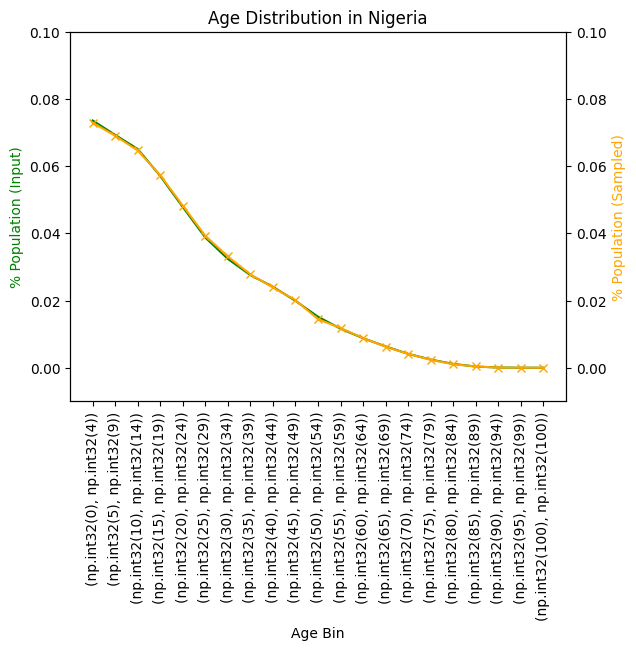

In [3]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plot histogram of samples on primary y-axis

fraction = nigeria[:, MCOL] / nigeria[:, MCOL : FCOL + 1].sum()
ax1.plot(fraction, color="green")
ax1.set_xlabel("Age Bin")
bins = [f"{i, j}" for i, j in zip(nigeria[:, MINCOL], nigeria[:, MAXCOL])]
plt.xticks(rotation=90)
ax1.set_xticks(ticks=range(len(bins)), labels=bins)
ax1.set_ylim(-0.01, 0.1)
ax1.set_ylabel("% Population (Input)", color="green")

# Create secondary y-axis
ax2 = ax1.twinx()

# We will calculate the histogram manually because the final bin isn't the same width as the others.
histogram = np.zeros(21, dtype=np.int32)
for i in range(histogram.shape[0]):
    mask = (ages // 1825) == i  # Convert ages in days to 5-year bin indices
    histogram[i] = mask.sum()

scale = nigeria[:, MCOL].sum() / nigeria[:, MCOL : FCOL + 1].sum()  # male / male+female
fraction = (histogram * scale) / histogram.sum()
ax2.plot(range(histogram.shape[0]), fraction, color="orange", marker="x")
ax2.set_ylim(-0.01, 0.1)
ax2.set_ylabel("% Population (Sampled)", color="orange")

plt.title("Age Distribution in Nigeria")
plt.show()

### Reading the Nigeria plot

The figure overlays two curves against the same age-bin axis (0–4 through 100+):

- **Green line — input distribution.** The male-population fraction in each 5-year bin, taken straight from the Nigeria 2024 pyramid.
- **Orange line with × markers — sampled distribution.** The empirical fraction of the 100,000 sampled agents that fell into each bin after `AliasedDistribution.sample()` followed by a uniform draw within each bin.

Both curves share the y-axis range 0–10%. The shape is the classic expansive pyramid: ~7.5% of the population in the youngest 0–4 bin, declining roughly monotonically to near-zero by age 80+. **The takeaway is that the orange sampled curve lies essentially on top of the green input curve across every bin** — visual confirmation that the alias sampler reproduces the source pyramid within Monte-Carlo noise at N=100k.


## United States

Source: https://www.populationpyramid.net/united-states-of-america/2024/

![U.S. Age Pyramid](./United%20States%20of%20America%20-%202024.png)

In [4]:
america = load_pyramid_csv(Path.cwd() / "United States of America-2024.csv")
sampler = AliasedDistribution(america[:, FCOL])  # We'll use the female population in this example.
n_agents = 100_000
samples = sampler.sample(n_agents)  # Sample 100,000 people from the distribution.
# samples will be bin indices, so we need to convert them to ages.
bin_min_age_days = america[:, MINCOL] * 365  # minimum age for bin, in days (include this value)
bin_max_age_days = (america[:, MAXCOL] + 1) * 365  # maximum age for bin, in days (exclude this value)
mask = np.zeros(n_agents, dtype=bool)
ages = np.zeros(n_agents, dtype=np.int32)
for i in range(len(america)):  # for each possible bin value...
    mask[:] = samples == i  # ...find the agents that belong to this bin
    # ...and assign a random age, in days, within the bin
    ages[mask] = np.random.randint(bin_min_age_days[i], bin_max_age_days[i], mask.sum())


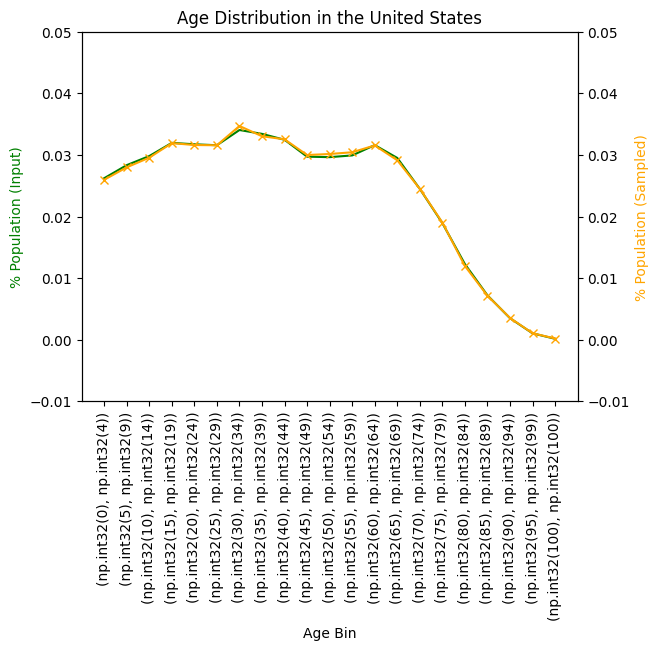

In [5]:
fig, ax1 = plt.subplots()

# Plot histogram of samples on primary y-axis

fraction = america[:, FCOL] / america[:, MCOL : FCOL + 1].sum()
ax1.plot(fraction, color="g")
ax1.set_xlabel("Age Bin")
plt.xticks(rotation=90)
bins = [f"{i, j}" for i, j in zip(america[:, MINCOL], america[:, MAXCOL])]
ax1.set_xticks(ticks=range(len(bins)), labels=bins)
ax1.set_ylim(-0.01, 0.05)
ax1.set_ylabel("% Population (Input)", color="g")

# We will calculate the histogram manually because the final bin isn't the same width as the others.
histogram = np.zeros(21, dtype=np.int32)
for i in range(histogram.shape[0]):
    mask = (ages // 1825) == i  # Convert ages in days to 5-year bin indices
    histogram[i] = mask.sum()

# Create secondary y-axis
ax2 = ax1.twinx()
scale = america[:, FCOL].sum() / america[:, MCOL : FCOL + 1].sum()  # female / male+female
fraction = (histogram * scale) / histogram.sum()
ax2.plot(range(histogram.shape[0]), fraction, color="orange", marker="x")
ax2.set_ylabel("% Population (Sampled)", color="orange")
ax2.set_ylim(-0.01, 0.05)


plt.title("Age Distribution in the United States")
plt.show()

### Reading the United States plot

Same two-curve overlay as the Nigeria figure, but for the U.S. 2024 female pyramid:

- **Green line — input fraction per 5-year bin** from the CSV.
- **Orange line with × markers — sampled fraction** over 100,000 draws.

Shared y-axis range is roughly -1% to 5%. The shape is the characteristic developed-country profile: a near-flat plateau around 2.6–3.4% from age 0 through about 64 (with a mild dip in the 45–54 working-age cohort and a small bulge around the 30–39 millennial cohort), followed by a steady decline through the retirement ages and down to near-zero by 95+. **The orange and green curves are again indistinguishable bin-by-bin**, confirming the sampler tracks a much flatter distribution just as faithfully as the Nigeria pyramid.